In [1]:
!pip install  tensorflow-federated

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 83.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of grpcio-tools to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-tools to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from re import X
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,roc_curve,confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
import tensorflow_federated as tff
from sklearn.datasets import load_breast_cancer
from tensorflow_federated import learning
from collections import defaultdict
import xgboost as xgb



ERROR:jax._src.xla_bridge:Jax plugin configuration error: Plugin module %s could not be loaded
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/jax/_src/xla_bridge.py", line 428, in discover_pjrt_plugins
    plugin_module = importlib.import_module(plugin_module_name)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/importlib/__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1147, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 690, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_r

In [8]:
!python3 --version

Python 3.11.13


In [6]:
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow Federated version: {tff.__version__}")
print(f"XGBoost version: {xgb.__version__}")

Pandas version: 2.2.2
Numpy version: 1.25.2
Seaborn version: 0.13.2
TensorFlow version: 2.14.1
TensorFlow Federated version: 0.87.0
XGBoost version: 3.0.2


# Loan Dataset

## Normal Training

In [ ]:
data = pd.read_csv('/content/loan-10k.lrn.csv')
final_X_test = pd.read_csv('/content/loan-10k.tes.csv')
final_Y_test = pd.read_csv('/content/loan-10k.sol.ex.csv')

y_train =  pd.DataFrame( data['grade'])
X_train =  pd.DataFrame( data.drop(['grade' , 'ID'], axis=1))
final_X_test =  pd.DataFrame( final_X_test.drop(['ID'], axis=1))

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

### Neural Networks

In [ ]:
le = LabelEncoder()
encoder = OneHotEncoder(handle_unknown='ignore')
#  for the features below we can use Label encoder, they seem ordinal
columns_to_transform = [
    'term', 'emp_length', 'verification_status', 'loan_status',
    'purpose', 'initial_list_status', 'application_type',
    'disbursement_method', 'debt_settlement_flag' ,'addr_state'
]

for column in columns_to_transform:
    X_train[column] = le.fit_transform(X_train[column])
    X_test[column] = le.transform(X_test[column])


y_train["grade"] = le.fit_transform(y_train["grade"])
y_test["grade"] = le.fit_transform(y_test["grade"])
y_train = y_train.to_numpy().flatten()
y_test = y_test.to_numpy().flatten()
# We can drop the columns 'pymnt_plan' and 'addr_state' beacuse they do not have any useful information
X_train = X_train.drop('pymnt_plan', axis=1)
X_train = X_train.drop('hardship_flag', axis=1)

X_test = X_test.drop('pymnt_plan', axis=1)
X_test = X_test.drop('hardship_flag', axis=1)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

encoded = encoder.fit_transform(X_train[['home_ownership']])
encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(['home_ownership']))
X_train = pd.concat([X_train, encoded_df], axis=1)
X_train = X_train.drop('home_ownership', axis=1)


encoded = encoder.transform(X_test[['home_ownership']])
encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(['home_ownership']))
X_test = pd.concat([X_test, encoded_df], axis=1)
X_test = X_test.drop('home_ownership', axis=1)

Features = X_train.columns
Features_not_scaled = ['term', 'emp_length', 'verification_status', 'loan_status',
    'purpose', 'initial_list_status', 'application_type',
    'disbursement_method', 'debt_settlement_flag' ,'addr_state' ,"home_ownership_ANY" ,
    "home_ownership_MORTGAGE" ,	"home_ownership_OTHER" ,	"home_ownership_OWN" ,  	"home_ownership_RENT" ]

Features_scaled = [x for x in Features if x not in Features_not_scaled]
scaler = StandardScaler()
X_train[Features_scaled] = scaler.fit_transform(X_train[Features_scaled])
X_test[Features_scaled] = scaler.transform(X_test[Features_scaled])


In [ ]:

# 2. Simulate federated data distribution
def create_federated_data(x, y, num_clients=100):
    num_classes = len(np.unique(y))
    class_indices = defaultdict(list)

    for i, label in enumerate(y):
        class_indices[label].append(i)

    client_data = []
    classes_per_client = max(4, num_classes // num_clients)
    all_classes = np.arange(num_classes)

    for _ in range(num_clients):
        selected_classes = np.random.choice(all_classes, classes_per_client, replace=False)
        client_indices = []

        for cls in selected_classes:
            cls_idxs = class_indices[cls]
            cls_sampled = np.random.choice(cls_idxs, min(len(cls_idxs), len(x)//(num_clients*classes_per_client)), replace=False)
            client_indices.extend(cls_sampled)

        np.random.shuffle(client_indices)
        client_x = x.iloc[client_indices].values.astype(np.float32)
        client_y = y[client_indices].astype(np.int32)
        ds = tf.data.Dataset.from_tensor_slices((client_x, client_y)).shuffle(100).batch(16).repeat(5)
        client_data.append(ds)

    return client_data


In [ ]:
def federated_Learning( X_train , y_train,X_test, y_test, number_of_clients):
  federated_train_data = create_federated_data(X_train, y_train ,number_of_clients)
  def create_keras_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(8, activation='tanh'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(4, activation='relu'),
        tf.keras.layers.Dense(7, activation='softmax')
    ])
  def model_fn():
    keras_model = create_keras_model()
    return tff.learning.models.from_keras_model(
    keras_model,
    input_spec=federated_train_data[0].element_spec,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

  trainer = learning.algorithms.build_weighted_fed_avg(
    model_fn=model_fn,
    client_optimizer_fn=learning.optimizers.build_adam(learning_rate=0.01),
    server_optimizer_fn=learning.optimizers.build_sgdm(learning_rate=0.1)
  )
  state = trainer.initialize()
  print(f"Starting federated training... for {number_of_clients} clients ")
  max_accuracy = 0
  counter = 0
  while True:
      state, metrics = trainer.next(state, federated_train_data)
      final_model = trainer.get_model_weights(state).trainable
      keras_model = create_keras_model()
      keras_model.set_weights(final_model)
      keras_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])
      loss, acc_test = keras_model.evaluate(X_test, y_test)
      if acc_test > max_accuracy:
        max_accuracy = acc_test
        counter = 0
      else:
        counter += 1

      if counter == 20:
        break


  return max_accuracy

In [ ]:
max_acc = []
nodes = []
i =1
while i <= 110:

  max_accuracy = federated_Learning( X_train , y_train,X_test, y_test,i)
  max_acc.append(max_accuracy)
  nodes.append(i)
  if i <=11 :
    i +=3
  else :
    i += 30

Starting federated training... for 1 clients 
32/32 [==============================] - 0s 2ms/step - loss: 0.2910 - accuracy: 0.8840
Starting federated training... for 4 clients 
32/32 [==============================] - 0s 2ms/step - loss: 4.5986 - accuracy: 0.5750
Starting federated training... for 7 clients 
32/32 [==============================] - 0s 2ms/step - loss: 2.7679 - accuracy: 0.4810
Starting federated training... for 10 clients 
32/32 [==============================] - 0s 3ms/step - loss: 5.3952 - accuracy: 0.5770
Starting federated training... for 13 clients 
32/32 [==============================] - 0s 2ms/step - loss: 0.7439 - accuracy: 0.7200
Starting federated training... for 43 clients 
32/32 [==============================] - 0s 2ms/step - loss: 0.6591 - accuracy: 0.7390
Starting federated training... for 73 clients 
32/32 [==============================] - 0s 2ms/step - loss: 0.6213 - accuracy: 0.7650
Starting federated training... for 103 clients 
32/32 [==========

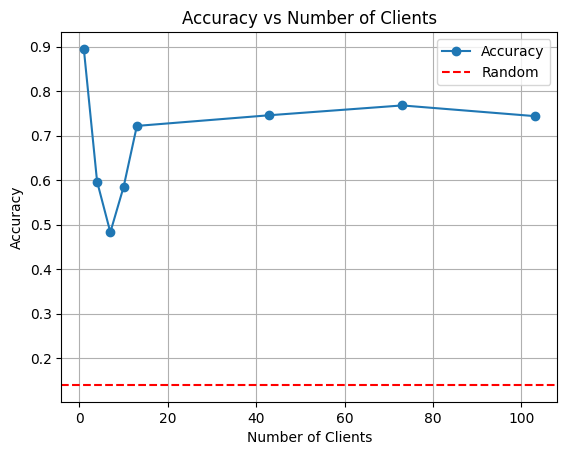

In [ ]:
plot1(nodes , max_acc)

### Centralize

In [ ]:
max_acc[0]

## Gradient Boosting Decision Tree Federated Learning




In [ ]:
data = pd.read_csv('/content/loan-10k.lrn.csv')
final_X_test = pd.read_csv('/content/loan-10k.tes.csv')
final_Y_test = pd.read_csv('/content/loan-10k.sol.ex.csv')

y_train =  pd.DataFrame( data['grade'])
X_train =  pd.DataFrame( data.drop(['grade' , 'ID'], axis=1))
final_X_test =  pd.DataFrame( final_X_test.drop(['ID'], axis=1))

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

In [ ]:
def create_federated_data(x, y, num_clients=100):
    num_classes = len(np.unique(y))
    class_indices = defaultdict(list)

    for i, label in enumerate(y):
        class_indices[label].append(i)

    client_data = []
    classes_per_client = max(4, num_classes // num_clients)
    all_classes = np.arange(num_classes)

    for _ in range(num_clients):
        selected_classes = np.random.choice(all_classes, classes_per_client, replace=False)
        client_indices = []

        for cls in selected_classes:
            cls_idxs = class_indices[cls]
            cls_sampled = np.random.choice(cls_idxs, min(len(cls_idxs), len(x)//(num_clients*classes_per_client)), replace=False)
            client_indices.extend(cls_sampled)

        np.random.shuffle(client_indices)
        client_x = x.iloc[client_indices].values.astype(np.float32)
        client_y = y[client_indices].astype(np.int32)
        client_data.append((client_x, client_y)) # Append a tuple of (features, labels) for each client

    return client_data

In [ ]:
le = LabelEncoder()
encoder = OneHotEncoder()
#  for the features below we can use Label encoder, they seem ordinal
columns_to_transform = [
    'term', 'emp_length', 'verification_status', 'loan_status',
    'purpose', 'initial_list_status', 'application_type',
    'disbursement_method', 'debt_settlement_flag','home_ownership','addr_state'
]

for column in columns_to_transform:
    X_train[column] = le.fit_transform(X_train[column])
    X_test[column] = le.fit_transform(X_test[column])
    final_X_test[column] = le.fit_transform(final_X_test[column])




# We can drop the columns 'pymnt_plan' and 'addr_state' beacuse they do not have any useful information
X_train = X_train.drop('pymnt_plan', axis=1)
X_train = X_train.drop('hardship_flag', axis=1)
final_X_test = final_X_test.drop('pymnt_plan', axis=1)
final_X_test = final_X_test.drop('hardship_flag', axis=1)

X_test = X_test.drop('pymnt_plan', axis=1)
X_test = X_test.drop('hardship_flag', axis=1)
le = LabelEncoder()

y_train = le.fit_transform(y_train.values.flatten())
y_test = le.transform(y_test.values.flatten())

In [ ]:
nodes = []
max_acc = []
for number_of_nodes in range(1, 100,3):
    client_data = create_federated_data(X_train, y_train, number_of_nodes)

    booster = None  # Shared model

    for i in range(number_of_nodes):
        X_client, y_client = client_data[i]
        dtrain = xgb.DMatrix(X_client, label=y_client, enable_categorical=True)

        booster = xgb.train(
            params={
                'objective': 'multi:softprob',
                'eval_metric': 'mlogloss',
                'num_class': 7,
                'verbosity': 0
            },
            dtrain=dtrain,
            num_boost_round=20,
            xgb_model=booster
        )

    dtest = xgb.DMatrix(X_test, enable_categorical=True)
    y_pred_proba = booster.predict(dtest)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {number_of_nodes} clients: {acc}")
    nodes.append(number_of_nodes)
    max_acc.append(acc)


Accuracy for 1 clients: 0.981
Accuracy for 4 clients: 0.596
Accuracy for 7 clients: 0.299
Accuracy for 10 clients: 0.197
Accuracy for 13 clients: 0.145
Accuracy for 16 clients: 0.691
Accuracy for 19 clients: 0.875
Accuracy for 22 clients: 0.808
Accuracy for 25 clients: 0.797
Accuracy for 28 clients: 0.862
Accuracy for 31 clients: 0.781
Accuracy for 34 clients: 0.776
Accuracy for 37 clients: 0.842
Accuracy for 40 clients: 0.806
Accuracy for 43 clients: 0.795
Accuracy for 46 clients: 0.72
Accuracy for 49 clients: 0.734
Accuracy for 52 clients: 0.765
Accuracy for 55 clients: 0.746
Accuracy for 58 clients: 0.75
Accuracy for 61 clients: 0.739
Accuracy for 64 clients: 0.797
Accuracy for 67 clients: 0.696
Accuracy for 70 clients: 0.756
Accuracy for 73 clients: 0.824
Accuracy for 76 clients: 0.685
Accuracy for 79 clients: 0.789
Accuracy for 82 clients: 0.75
Accuracy for 85 clients: 0.778
Accuracy for 88 clients: 0.793
Accuracy for 91 clients: 0.656
Accuracy for 94 clients: 0.734
Accuracy for 9

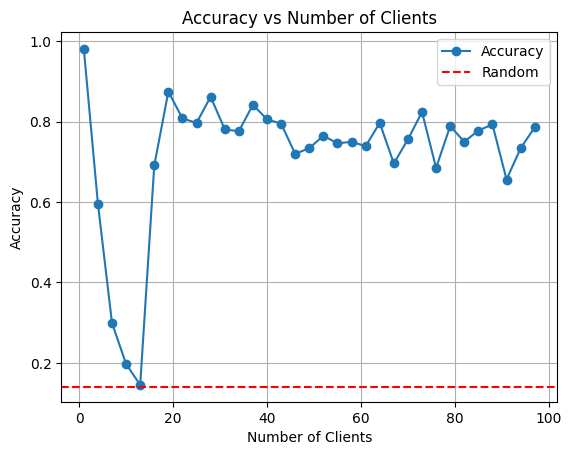

In [ ]:
plot1(nodes , max_acc)

In [ ]:
max_acc[0]

0.317

# Dataset Cancer


In [ ]:


data = pd.read_csv('/content/breast-cancer-diagnostic.shuf.lrn.csv')
final_X_test = pd.read_csv('/content/breast-cancer-diagnostic.shuf.tes.csv')
final_Y_test = pd.read_csv('/content/breast-cancer-diagnostic.shuf.sol.ex.csv')

y_train =  pd.DataFrame( data['class'])
X_train =  pd.DataFrame( data.drop(['class' , 'ID'], axis=1))
final_X_test =  pd.DataFrame( final_X_test.drop(['ID'], axis=1))

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)


# Normalization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
final_X_test = scaler.transform(final_X_test)



In [ ]:
# 2. Simulate federated data distribution
def create_federated_data(x, y, num_clients=100):
    num_classes = len(np.unique(y))
    class_indices = defaultdict(list)

    for i, label in enumerate(y):
        class_indices[label].append(i)

    client_data = []
    classes_per_client = max(2 ,  num_classes // num_clients)
    all_classes = np.arange(num_classes)

    for _ in range(num_clients):
        selected_classes = np.random.choice(all_classes, classes_per_client, replace=False)
        client_indices = []

        for cls in selected_classes:
            cls_idxs = class_indices[cls]
            cls_sampled = np.random.choice(cls_idxs, min(len(cls_idxs), len(x)//(num_clients*classes_per_client)), replace=False)
            client_indices.extend(cls_sampled)

        np.random.shuffle(client_indices)
        client_x = x.iloc[client_indices].values.astype(np.float32)
        client_y = y[client_indices].astype(np.int32)
        ds = tf.data.Dataset.from_tensor_slices((client_x, client_y)).shuffle(100).batch(16).repeat(5)
        client_data.append(ds)

    return client_data

In [ ]:
def federated_Learning( X_train , y_train,X_test, y_test, number_of_clients):
  # Convert NumPy arrays back to DataFrames
  X_train_df = pd.DataFrame(X_train)
  X_test_df = pd.DataFrame(X_test)
  # Flatten y_train to a 1D NumPy array
  y_train_flat = y_train.values.flatten()
  federated_train_data = create_federated_data(X_train_df, y_train_flat ,number_of_clients)
  def create_keras_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(8, activation='tanh'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(4, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
  def model_fn():
    keras_model = create_keras_model()
    return tff.learning.models.from_keras_model(
    keras_model,
    input_spec=federated_train_data[0].element_spec,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.BinaryAccuracy()]
)

  trainer = learning.algorithms.build_weighted_fed_avg(
    model_fn=model_fn,
    client_optimizer_fn=learning.optimizers.build_adam(learning_rate=0.01),
    server_optimizer_fn=learning.optimizers.build_sgdm(learning_rate=0.1)
  )
  state = trainer.initialize()
  print(f"Starting federated training... for {number_of_clients} clients ")
  max_accuracy = 0
  counter = 0
  while True:
      state, metrics = trainer.next(state, federated_train_data)
      final_model = trainer.get_model_weights(state).trainable
      keras_model = create_keras_model()
      keras_model.set_weights(final_model)
      keras_model.compile(loss=tf.keras.losses.BinaryCrossentropy(), metrics=['accuracy'])
      loss, acc_test = keras_model.evaluate(X_test, y_test)
      if acc_test > max_accuracy:
        max_accuracy = acc_test
        counter = 0
      else:
        counter += 1
      if counter == 10:
        break


  return max_accuracy

In [ ]:
max_acc = []
nodes = []
i =1
while i <= 110:
  max_accuracy = federated_Learning( X_train , y_train,X_test, y_test,i)
  max_acc.append(max_accuracy)
  nodes.append(i)
  if i <=11 :
    i +=3
  else :
    i += 30

Starting federated training... for 1 clients 
1/1 [==============================] - 0s 231ms/step - loss: 0.1470 - accuracy: 0.9655
Starting federated training... for 4 clients 
1/1 [==============================] - 0s 233ms/step - loss: 0.2302 - accuracy: 0.9655
Starting federated training... for 7 clients 
1/1 [==============================] - 0s 270ms/step - loss: 0.0952 - accuracy: 0.9655
Starting federated training... for 10 clients 
1/1 [==============================] - 0s 253ms/step - loss: 0.2147 - accuracy: 0.8966
Starting federated training... for 13 clients 
1/1 [==============================] - 0s 216ms/step - loss: 0.3580 - accuracy: 0.8966
Starting federated training... for 43 clients 
1/1 [==============================] - 0s 240ms/step - loss: 0.2156 - accuracy: 0.8966
Starting federated training... for 73 clients 
1/1 [==============================] - 0s 229ms/step - loss: 0.4170 - accuracy: 0.8966
Starting federated training... for 103 clients 
1/1 [============

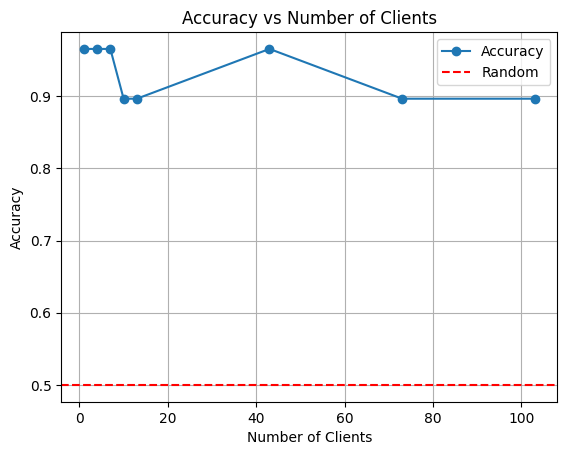

In [ ]:
plot1(nodes , max_acc)

## Gradient Boosting Decision Tree Federated Learning


In [ ]:
data = pd.read_csv('/content/breast-cancer-diagnostic.shuf.lrn.csv')
final_X_test = pd.read_csv('/content/breast-cancer-diagnostic.shuf.tes.csv')
final_Y_test = pd.read_csv('/content/breast-cancer-diagnostic.shuf.sol.ex.csv')

y_train =  pd.DataFrame( data['class'])
X_train =  pd.DataFrame( data.drop(['class' , 'ID'], axis=1))
final_X_test =  pd.DataFrame( final_X_test.drop(['ID'], axis=1))

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)


# Normalization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
final_X_test = scaler.transform(final_X_test)


In [ ]:
def create_federated_data(x, y, num_clients=100):
    # Ensure y is a NumPy array
    y = np.asarray(y)
    num_classes = len(np.unique(y))
    class_indices = defaultdict(list)

    for i, label in enumerate(y):
        # Convert label to a hashable type (e.g., int)
        class_indices[int(label)].append(i)

    client_data = []
    classes_per_client = max(1, num_classes // num_clients)
    all_classes = np.arange(num_classes)

    for _ in range(num_clients):
        selected_classes = np.random.choice(all_classes, classes_per_client, replace=False)
        client_indices = []

        for cls in selected_classes:
            cls_idxs = class_indices[cls]
            cls_sampled = np.random.choice(cls_idxs, min(len(cls_idxs), len(x)//(num_clients*classes_per_client)), replace=False)
            client_indices.extend(cls_sampled)

        np.random.shuffle(client_indices)
        client_x = x[client_indices].astype(np.float32)
        client_y = y[client_indices].astype(np.int32)
        client_data.append((client_x, client_y)) # Append a tuple of (features, labels) for each client

    return client_data

In [ ]:
nodes = []
max_acc = []
for number_of_nodes in range(1, 100,3):
    client_data = create_federated_data(X_train, y_train, number_of_nodes)

    # Only proceed if there is data for at least one client
    if client_data:
        booster = None  # Shared model

        for X_client, y_client in client_data: # Iterate directly over client_data
            dtrain = xgb.DMatrix(X_client, label=y_client, enable_categorical=True)

            booster = xgb.train(
                params={
                    'objective': 'multi:softprob',
                    'eval_metric': 'mlogloss',
                    'num_class': 2,
                    'verbosity': 0
                },
                dtrain=dtrain,
                num_boost_round=20,
                xgb_model=booster
            )

        dtest = xgb.DMatrix(X_test, enable_categorical=True)
        y_pred_proba = booster.predict(dtest)
        y_pred = np.argmax(y_pred_proba, axis=1)

        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy for {number_of_nodes} clients: {acc}")
        nodes.append(number_of_nodes)
        max_acc.append(acc)
    else:
        print(f"Skipping training for {number_of_nodes} clients due to empty client data.")

/tmp/ipython-input-25-1056804994.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_indices[int(label)].append(i)
/tmp/ipython-input-25-1056804994.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_indices[int(label)].append(i)
/tmp/ipython-input-25-1056804994.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_indices[int(label)].append(i)


Accuracy for 1 clients: 0.896551724137931
Accuracy for 4 clients: 0.6551724137931034
Accuracy for 7 clients: 0.6551724137931034


/tmp/ipython-input-25-1056804994.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_indices[int(label)].append(i)


Accuracy for 10 clients: 0.6551724137931034


/tmp/ipython-input-25-1056804994.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_indices[int(label)].append(i)


...

Accuracy for 91 clients: 0.6551724137931034


/tmp/ipython-input-25-1056804994.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_indices[int(label)].append(i)


Accuracy for 94 clients: 0.6551724137931034


/tmp/ipython-input-25-1056804994.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_indices[int(label)].append(i)


Accuracy for 97 clients: 0.3448275862068966


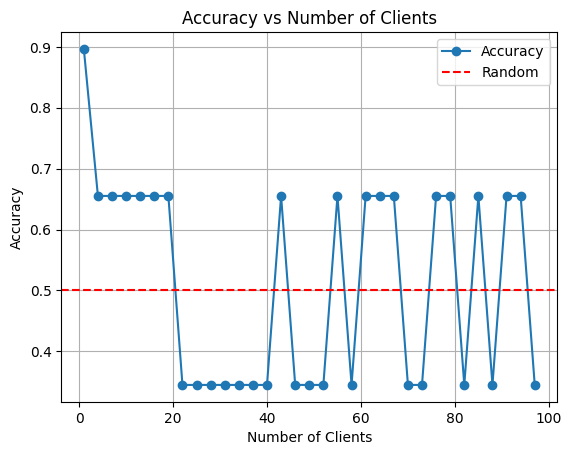

In [ ]:
plot1(nodes , max_acc)

## Appendix

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
def plot1(x, y):
    plt.plot(x, y,  marker='o',label='Accuracy')
    plt.axhline(y=0.5, color='red', linestyle='--', label='Random')
    plt.xlabel('Number of Clients')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Number of Clients')
    plt.legend()
    plt.grid(True)
    plt.show()